In [1]:
import torch
import torch.nn as nn

import torch_geometric as tg
import torch_geometric.utils as tgu
import torch_geometric.nn as tgnn
import matplotlib.pyplot as plt

import numpy as np
from sklearn.preprocessing import OneHotEncoder

In [5]:
! ls sequences/

data


In [6]:
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')
print(DEVICE)

cuda


## Notes from graphcast
 - there are multiple layers of nodes -> some nodes propagate information to more distant nodes
 - loss function takes into account multiple factors - e.g. sample density
 - autoregressive training 
   - model is trained using fix interval
   - to predict more distant (in time) points then previous prediction of a model is used
   - predicting 10 day ahead tends to have large overfitting
 - gnn was selected because weather function is the same in every place of the globe

In [10]:
import sys
sys.path.append('sequences')

In [11]:
import data.d1 as dataset_module

In [12]:
samples, test_names, units = dataset_module.load_dataset()
samples = [*filter(lambda x: len(x)>10, samples)]
print([len(i) for i in samples])

[35, 31, 43, 40, 43, 40]


/workspace/sequences/data/d1/__init__.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['date'] = data.apply(lambda x: dateparse(x['data']), axis=1)


In [64]:
name_enc = OneHotEncoder()
unit_enc = OneHotEncoder()

name_enc.fit([[i] for i in test_names])
unit_enc.fit([[i] for i in units.keys()])


def scale_value(unit_name, value, units):
    min, max = units[unit_name]
    if np.isnan(max):
        max = 6*min+.000001
    return (value - min) / (max-min)

def reverse_scale_value(unit_name, value, units):
    min, max = units[unit_name]
    if np.isnan(max):
        max = 6*min+.000001
    return value * (max-min) + min

def get_sample(samples, units, inclusion_prob=0.5):
    sample_idx = np.random.randint(0, len(samples))
    sample = samples[sample_idx]

    nof_tests = len(sample)

    fully_connected_adj = torch.ones(nof_tests, nof_tests)
    fully_connected = tgu.dense_to_sparse(fully_connected_adj)[0]

    names_encoded = name_enc.transform([[_sample[0]] for _sample in sample]).toarray()
    units_encoded = unit_enc.transform([[_sample[2]] for _sample in sample]).toarray()

    model_input = []
    model_output = []
    is_included = np.random.random(nof_tests) < inclusion_prob
    for idx, included in zip(range(nof_tests), is_included):
        model_input.append(np.concatenate([
            names_encoded[idx], #test_name_encoded
            units_encoded[idx], # unit uncoded
            np.array([included*1.0]),
            np.array([scale_value(sample[idx][2], sample[idx][1], units) * included])
        ]))

        model_output.append(np.concatenate([
            names_encoded[idx], #test_name_encoded
            units_encoded[idx], # unit uncoded
            np.array([1.0]),
            np.array([scale_value(sample[idx][2], sample[idx][1], units)]) # scaled_value
        ]))
    return tg.data.Data(
        x=torch.tensor(np.array(model_input),dtype=torch.float32),
        edge_index=fully_connected,
        y=torch.tensor(np.array(model_output), dtype=torch.float32),
    )
    # return tg.data.Data(
    #     x=torch.tensor(sample, dtype=torch.float32, requires_grad=False),
    #     edge_index=torch.tensor(fully_connected, dtype=torch.int64, requires_grad=False),
    #     y=torch.tensor(sample_dt, dtype=torch.float32, requires_grad=False)
    # )

In [65]:
s = get_sample(samples, units)

In [54]:
feature_vector_len = 25
edge_vector_len = 200

class AutoEncoder(nn.Module):
    def __init__(self, input_size, hidden_size=8, input_size_expander=4):
        nn.Module.__init__(self)
        
        # Set the number of hidden units
        self.num_hidden = hidden_size
        
        # Define the encoder part of the autoencoder
        self.encoder = nn.Sequential(
            nn.Linear(input_size, input_size_expander*input_size),  # input size: 784, output size: 256
            nn.GELU(),  # apply the ReLU activation function
            nn.Linear(input_size_expander*input_size, self.num_hidden),  # input size: 256, output size: num_hidden
            nn.GELU(),  # apply the ReLU activation function
        )
        
        # Define the decoder part of the autoencoder
        self.decoder = nn.Sequential(
            nn.Linear(self.num_hidden, input_size_expander*input_size),  # input size: num_hidden, output size: 256
            nn.GELU(),  # apply the ReLU activation function
            nn.Linear(input_size_expander*input_size, input_size_expander*input_size),  # input size: num_hidden, output size: 256
            nn.GELU(),  # apply the ReLU activation function
            nn.Linear(input_size_expander*input_size, input_size),  # input size: 256, output size: 784
        )

    def forward(self, x):
        # Pass the input through the encoder
        encoded = self.encoder(x)
        # Pass the encoded representation through the decoder
        decoded = self.decoder(encoded)
        # Return both the encoded representation and the reconstructed output
        return encoded, decoded

In [55]:
ae = AutoEncoder(95, hidden_size=feature_vector_len, input_size_expander=4)
ae_dataset = torch.cat([get_sample(samples,units).x for _ in range(4096)])
batch_size = 64
num_epochs = 4

optimizer = torch.optim.Adam(ae.parameters(), lr=1e-3)

# Define the loss function
criterion = nn.MSELoss()

# Set the device to GPU if available, otherwise use CPU
ae.to(DEVICE)

# Create a DataLoader to handle batching of the training data
train_loader = torch.utils.data.DataLoader(
    ae_dataset, batch_size=64, shuffle=True
)

for epoch in range(num_epochs):
    total_loss = 0.0
    for batch_idx, data in enumerate(train_loader):
        # Get a batch of training data and move it to the device
        data = data.to(DEVICE)

        # Forward pass
        encoded, decoded = ae(data)

        # Compute the loss and perform backpropagation
        loss = criterion(decoded, data)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Update the running loss
        total_loss += loss.item() * data.size(0)

    # Print the epoch loss
    epoch_loss = total_loss / len(train_loader.dataset)
    print(
        "Epoch {}/{}: loss={:.6f}".format(epoch + 1, num_epochs, epoch_loss)
    )

Epoch 1/4: loss=0.001162
Epoch 2/4: loss=0.000017
Epoch 3/4: loss=0.000016
Epoch 4/4: loss=0.000016


In [56]:
sample = get_sample(samples, units)
ae.decoder(
    ae.encoder(sample.x.to(DEVICE))
)

tensor([[-1.8763e-03,  2.0792e-03,  6.7197e-04,  ...,  6.5049e-03,
          6.6238e-03, -5.9059e-03],
        [ 6.9912e-04, -8.0715e-04, -2.1842e-04,  ...,  9.1181e-04,
          1.1006e-02,  4.3907e-03],
        [-3.8520e-04, -1.3397e-03,  1.2963e-03,  ...,  7.3017e-03,
          1.0276e-02,  2.1961e-03],
        ...,
        [-1.0150e-03, -2.2705e-03,  1.4250e-03,  ...,  4.9039e-03,
         -3.2108e-04,  6.8910e-03],
        [ 5.4334e-04, -6.0739e-03, -2.0537e-03,  ...,  9.2086e-05,
          1.0097e+00,  3.5520e-02],
        [-5.0403e-03,  1.4788e-03,  7.7617e-05,  ..., -1.2226e-02,
         -8.2612e-03,  7.8452e-04]], device='cuda:0', grad_fn=<AddmmBackward0>)

In [57]:
# x_cord, y_cord, time
# time_embed 
ae.decoder.requires_grad_(False)
ae.encoder.requires_grad_(False)

class gnn_model(nn.Module):
    def __init__(self):
        nn.Module.__init__(self)
        self.gnn_out_ch = 32
        self.edge_vector_len = edge_vector_len
        edge_params_shape = len(test_names)
        self.fe = ae.encoder
        self.fd = ae.decoder
        self.edge_params = nn.Parameter(torch.randn([1, self.edge_vector_len])/20)

        self.l1 = tgnn.GAT(
            in_channels=feature_vector_len,
            hidden_channels=400,
            num_layers=3,
            out_channels=feature_vector_len,
            dropout=0.1,
            act='gelu',
            edge_dim=self.edge_vector_len,
            v2=True,
        )

    def forward(self, data):
        nodes = data.x
        edges = data.edge_index
        encoded_features = self.fe(nodes)

        g_output = self.l1(encoded_features, edges, edge_attr=torch.cat([self.edge_params]*edges.shape[1]))
        decoded = self.fd(g_output)

        return decoded[:,-1:]



In [58]:
model = gnn_model()
model.to(DEVICE)
with torch.no_grad():
    model(sample.to(DEVICE)).shape

In [ ]:
NUM_TR_STEPS = 80
BATCH_SIZE = 32
model.training_mode = True
loss_t_0 = []
loss_t_dt = []
optimizer = torch.optim.AdamW(model.parameters(),lr=2e-3,)
loss_fn = nn.MSELoss()
dl = tg.data.DataLoader([get_sample(samples, units) for _ in range(4096)], batch_size=2)

print('starting training')
for i in range(NUM_TR_STEPS):
    for idx, batch in enumerate(dl):
        print(f"IDX: {idx}", end='\r')
        batch = batch.to(DEVICE)
        y_hat = model(batch)

        loss = loss_fn(batch.y[:,-1], y_hat[:,-1])

        # check if this is correct place for zero grad
        optimizer.zero_grad()
        loss.backward()

        optimizer.step()

        if idx%8 == 0 and i>=2:
            l_dt = loss.detach().cpu().item()
            loss_t_dt.append(l_dt)
            print(f"l_dt:{l_dt}")
        elif idx%256 == 0 and i<2:
            l_dt = loss.detach().cpu().item()
            loss_t_dt.append(l_dt)
            print(f"l_dt:{l_dt}")
    if i == 1:
        print('generating new ds')
        dl = tg.data.DataLoader([get_sample(samples, units) for _ in range(4096)], batch_size=BATCH_SIZE)
    



/opt/conda/lib/python3.11/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


starting training
l_dt:0.21826119720935822
l_dt:0.15048269927501678
l_dt:0.0904628187417984
l_dt:0.1432083547115326
l_dt:0.13439606130123138
l_dt:0.12883241474628448
l_dt:0.13423119485378265
l_dt:0.1415732502937317
l_dt:0.14214223623275757
l_dt:0.15002289414405823
l_dt:0.09044042974710464
l_dt:0.1421307772397995
l_dt:0.13409534096717834
l_dt:0.12913988530635834
l_dt:0.1339794397354126
l_dt:0.1423221379518509
generating new ds


/opt/conda/lib/python3.11/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


l_dt:0.11728846281766891
l_dt:0.12347345054149628
l_dt:0.12213300168514252
l_dt:0.12063184380531311
l_dt:0.12848754227161407
l_dt:0.12414895743131638
l_dt:0.1098538413643837
l_dt:0.11860630661249161
l_dt:0.11569596081972122
l_dt:0.12040302157402039
l_dt:0.12432947754859924
l_dt:0.11920031905174255
l_dt:0.11757878959178925
l_dt:0.11739038676023483
l_dt:0.11661392450332642
l_dt:0.1256875842809677
l_dt:0.1170928031206131
l_dt:0.12332140654325485
l_dt:0.12201524525880814
l_dt:0.12073874473571777
l_dt:0.12831370532512665
l_dt:0.12421628832817078
l_dt:0.10994001477956772
l_dt:0.11863081157207489
l_dt:0.11568833887577057
l_dt:0.1203911080956459
l_dt:0.12427981942892075
l_dt:0.11918121576309204
l_dt:0.11757036298513412
l_dt:0.11740244925022125
l_dt:0.11659464985132217
l_dt:0.12570101022720337
l_dt:0.11712264269590378
l_dt:0.12326173484325409
l_dt:0.12201648205518723
l_dt:0.12070883810520172
l_dt:0.12833301723003387
l_dt:0.12422061711549759
l_dt:0.10994899272918701
l_dt:0.11865861713886261
l_dt

KeyboardInterrupt: 

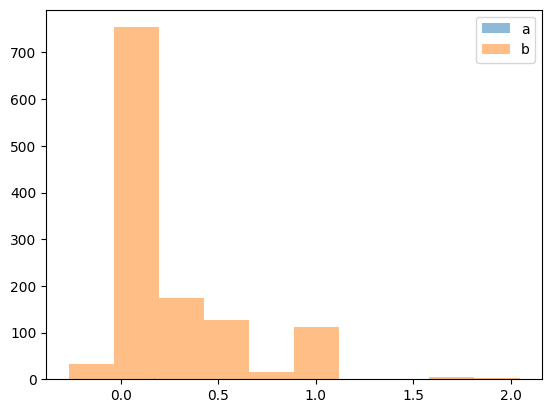

In [76]:
plt.hist(y_hat.detach().cpu().numpy().flatten(),alpha=0.5, label='a')
plt.hist(batch.y[:,-1].cpu().numpy().flatten(),alpha=0.5, label='b')
plt.legend()
plt.show()

In [77]:
batch.y[:,-1].mean()

tensor(0.2297, device='cuda:0')

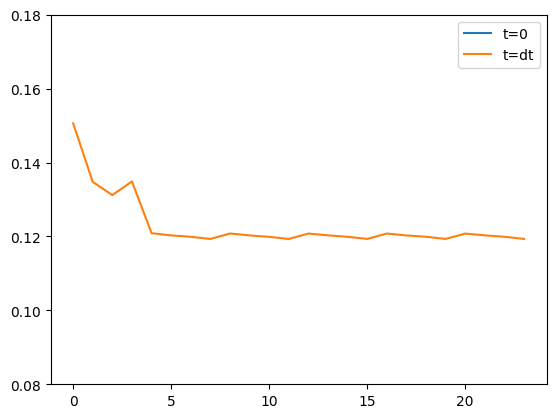

In [60]:
mean_over = 4
t0 = np.array([torch.mean(x).item() for x in loss_t_0])
t0_mean = t0[t0.shape[0]%mean_over:].reshape([-1,mean_over]).mean(axis=1)

t_dt = np.array(loss_t_dt)
t_dt_mean = t_dt[t_dt.shape[0]%mean_over:].reshape([-1,mean_over]).mean(axis=1)

plt.plot(t0_mean, label='t=0')
plt.plot(t_dt_mean, label='t=dt')
plt.legend()
plt.ylim(0.08,.18)
plt.show()

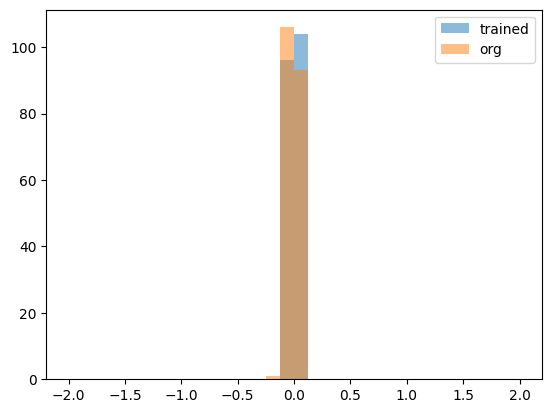

In [61]:
plt.hist(model.edge_params.detach().flatten().cpu(), bins=32, label='trained', alpha=0.5,range=(-2,2))
plt.hist((torch.randn(model.edge_params.shape)/20).flatten(), bins=32, label='org', alpha=0.5,range=(-2,2))
plt.legend()
plt.show()

MSE: 0.1162324845790863
MSE: 0.12526491284370422
MSE: 0.12445984035730362


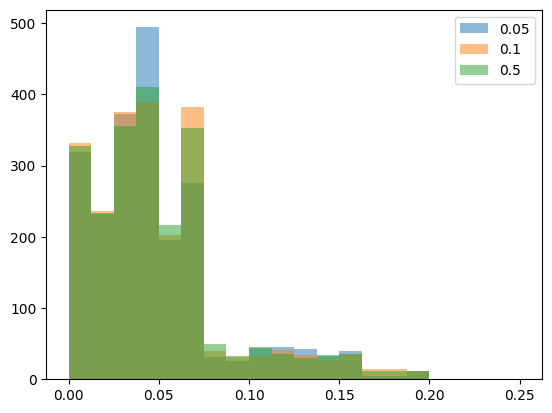

RMSE: 0.26519086956977844
RMSE: 0.2699514925479889
RMSE: 0.27052655816078186


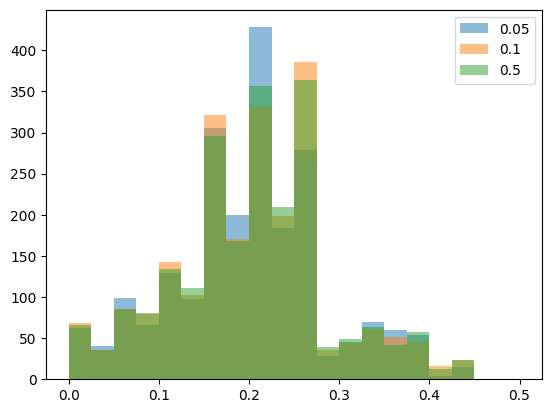

In [66]:
NUM_TEST_STEPS = 64
res_dict = {}
model.training_mode = False
with torch.no_grad():
    for inc_prob in [.05,.1,.5]:
        loss_te_dt = []
        for i in range(NUM_TEST_STEPS):
            sample = get_sample(samples, units,inclusion_prob=inc_prob).to(DEVICE)

            y_hat = model(
                sample
            )

            l_dt = ((sample.y[:,-1] - y_hat[:,-1])**2).T
            loss_te_dt.append(l_dt.detach())
        res_dict[inc_prob] = torch.cat(loss_te_dt).cpu().numpy()

for label, part_res in res_dict.items():
    plt.hist(part_res,range=(0,.25), alpha=0.5, label=str(label), bins=20)
    print(f"MSE: {np.mean(part_res)}")
plt.legend()
plt.show()

for label, part_res in res_dict.items():
    plt.hist(part_res**0.5,range=(0,.5), alpha=0.5, label=str(label), bins=20)
    print(f"RMSE: {np.mean(part_res**0.5)}")
plt.legend()
plt.show()

MSE: 0.17092175781726837
MSE: 0.15686503052711487
MSE: 0.14559249579906464
MSE: 0.08899862319231033


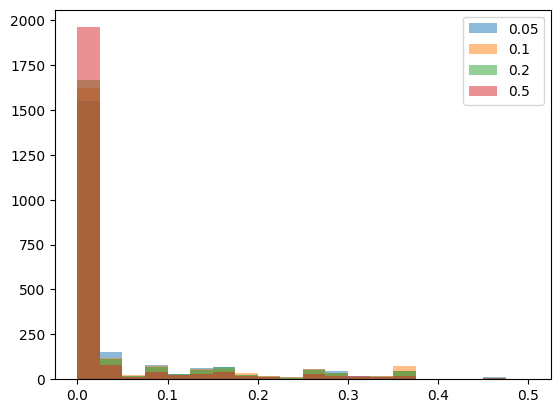

RMSE: 0.2303587794303894
RMSE: 0.21928653120994568
RMSE: 0.19718784093856812
RMSE: 0.11889763921499252


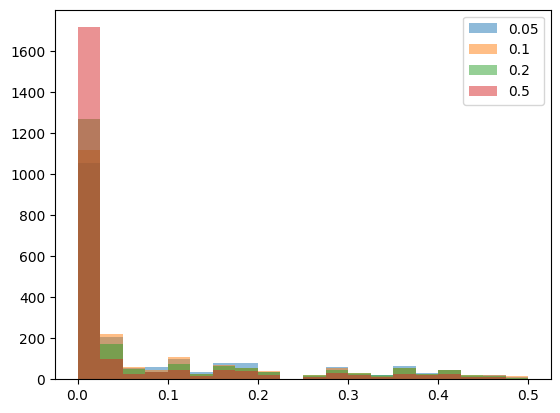

In [67]:
NUM_TEST_STEPS = 64
res_dict = {}

with torch.no_grad():
    for inc_prob in [.05,.1,.2,.5]:
        loss_te_dt = []
        for i in range(NUM_TEST_STEPS):
            sample = get_sample(samples, units,inclusion_prob=inc_prob)

            l_dt = ((sample.y[:,-1] - sample.x[:,-1])**2).T
            loss_te_dt.append(l_dt.detach())
        res_dict[inc_prob] = torch.cat(loss_te_dt).cpu().numpy()

for label, part_res in res_dict.items():
    plt.hist(part_res,range=(0,.5), alpha=0.5, label=str(label), bins=20)
    print(f"MSE: {np.mean(part_res)}")
plt.legend()
plt.show()

for label, part_res in res_dict.items():
    plt.hist(part_res**0.5,range=(0,.5), alpha=0.5, label=str(label), bins=20)
    print(f"RMSE: {np.mean(part_res**0.5)}")
plt.legend()
plt.show()

In [47]:
sample.x

tensor([[0.0000, 0.0000, 0.0000,  ..., 0.0000, 1.0000, 0.2759],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 1.0000, 0.1096],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        ...,
        [0.0000, 0.0000, 0.0000,  ..., 1.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 1.0000, 0.0400],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]])

In [48]:
sample.y

tensor([[0.0000, 0.0000, 0.0000,  ..., 0.0000, 1.0000, 0.2759],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 1.0000, 0.1096],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 1.0000, 0.6000],
        ...,
        [0.0000, 0.0000, 0.0000,  ..., 1.0000, 1.0000, 0.0706],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 1.0000, 0.0400],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 1.0000, 0.1798]])